<a href="https://colab.research.google.com/github/aidizzackyharizulfadly/HEKAS-POS/blob/main/TUGAS_UAS_VISUALISASIDATA_FIX_%26_MODELLING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warningswarnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# 2. Upload file: dataset_persentasi_uas.xlsx
from google.colab import files
uploaded = files.upload()
df = pd.read_excel('dataset persentasi uas.xlsx')

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"📊 Total Rows: {df.shape[0]:,}")
print(f"📊 Total Columns: {df.shape[1]}")

In [ ]:
#--- 3. EXPLORATORY DATA ANALYSIS (EDA) ---
print("\n" + "="*50)
print("📋 DATA OVERVIEW")
print("="*50)

print("\n🔍 First 5 Rows:")
print(df.head())

print("\n📝 Column Names:")
print(df.columns.tolist())

print("\n📊 Data Types:")
print(df.dtypes)

print("\n📈 Descriptive Statistics:")
print(df.describe())


📋 DATA OVERVIEW

🔍 First 5 Rows:
  Student_Type  Sleep_Hours  Study_Hours  Social_Media_Hours  Attendance  \
0       school     6.868702     1.711722            3.176942         NaN   
1       school     8.519088     3.251084            3.880787   93.978465   
2      college     4.498770     6.306885            2.936172   64.421253   
3       school     8.591223     2.384922            5.222832   81.868960   
4      college     5.329293     9.345179            7.815869   85.847982   

   Exam_Pressure  Family_Support  Month  Stress_Level  
0            8.0             7.0    2.0             1  
1            6.0             4.0    3.0             1  
2            7.0             1.0   12.0             1  
3            2.0             7.0    7.0             0  
4            5.0             6.0   10.0             1  

📝 Column Names:
['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance', 'Exam_Pressure', 'Family_Support', 'Month', 'Stress_Level']

📊 Data Types

In [ ]:
# 4. DATA HEALTH CHECK
print("\n" + "="*50)
print("🏥 DATA HEALTH CHECK")
print("="*50)

# Missing Values
# Missing value per baris
missing_per_baris = df.isnull().sum(axis=1)  # axis=1 = hitung per baris

print("=== MISSING VALUE PER BARIS ===")
print(f"Baris tanpa missing  : {(missing_per_baris == 0).sum():,}")
print(f"Baris ada 1 missing  : {(missing_per_baris == 1).sum():,}")
print(f"Baris ada 2 missing  : {(missing_per_baris == 2).sum():,}")
print(f"Baris ada 3+ missing : {(missing_per_baris >= 3).sum():,}")
print(f"\nTotal baris          : {len(df):,}")
print(f"Total baris missing  : {(missing_per_baris > 0).sum():,}")
print(f"Persentase           : {(missing_per_baris > 0).sum() / len(df) * 100:.2f}%")
# Duplicates
print(f"\n🔄 Duplicate Rows: {df.duplicated().sum()}")

# Outliers (IQR Method)
print("\n📊 Outliers Detection (IQR Method):")
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) |
                 (df[col] > (Q3 + 1.5 * IQR))).sum()
    if outliers > 0:
        print(f"  - {col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

# Hitung distribusi target
target_counts = df_clean['Stress_Level'].value_counts()
target_pct = df_clean['Stress_Level'].value_counts(normalize=True) * 100

print("\n=== CEK DATA IMBALANCE ===")
print(f"Stress_Level = 0 (Tidak Stres) : {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Stress_Level = 1 (Stres)        : {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\nRasio 0:1 = {target_counts[0]/target_counts[1]:.2f}:1")




🏥 DATA HEALTH CHECK
=== MISSING VALUE PER BARIS ===
Baris tanpa missing  : 16,809
Baris ada 1 missing  : 7,203
Baris ada 2 missing  : 1,323
Baris ada 3+ missing : 165

Total baris          : 25,500
Total baris missing  : 8,691
Persentase           : 34.08%

🔄 Duplicate Rows: 24

📊 Outliers Detection (IQR Method):
  - Sleep_Hours: 64 outliers (0.25%)
  - Study_Hours: 164 outliers (0.64%)
  - Social_Media_Hours: 57 outliers (0.22%)
  - Attendance: 177 outliers (0.69%)

=== CEK DATA IMBALANCE ===
Stress_Level = 0 (Tidak Stres) : 17,837 (70.01%)
Stress_Level = 1 (Stres)        : 7,639 (29.99%)

Rasio 0:1 = 2.33:1



📈 VISUALIZATION


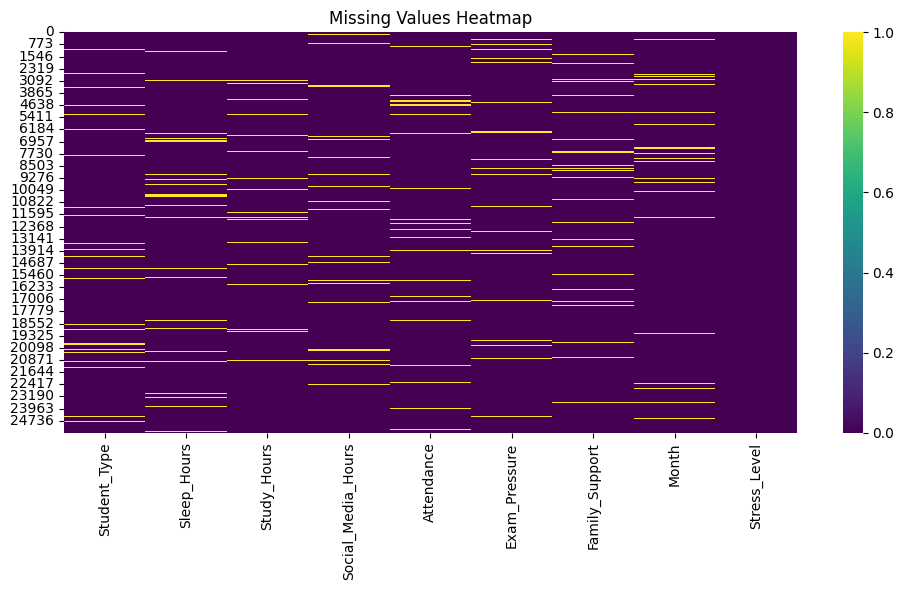

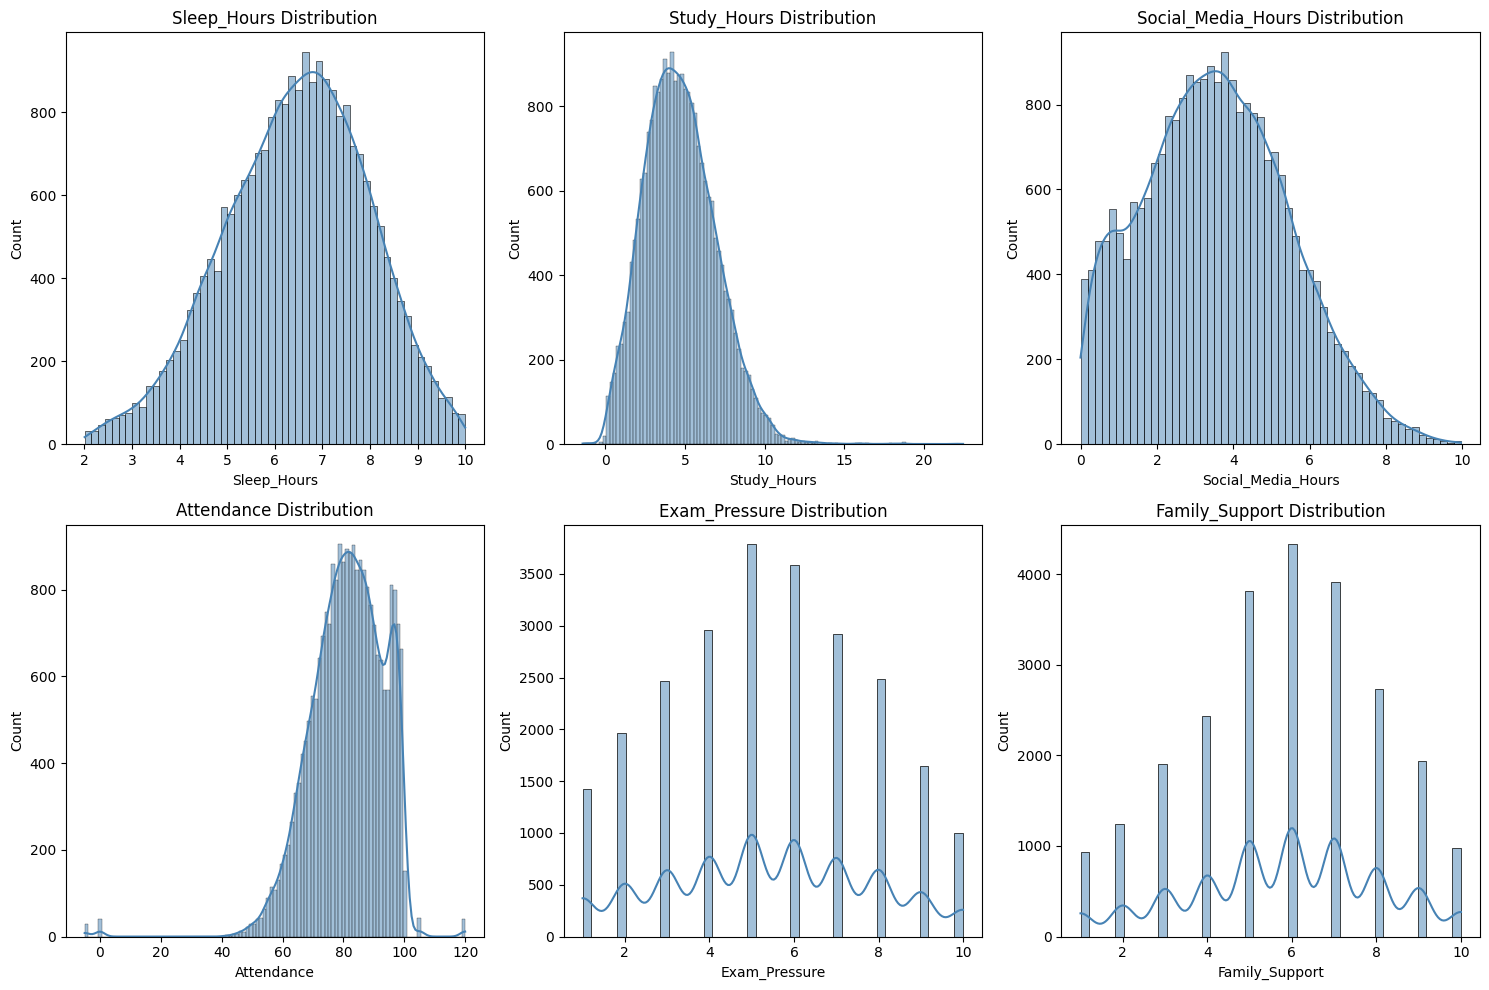

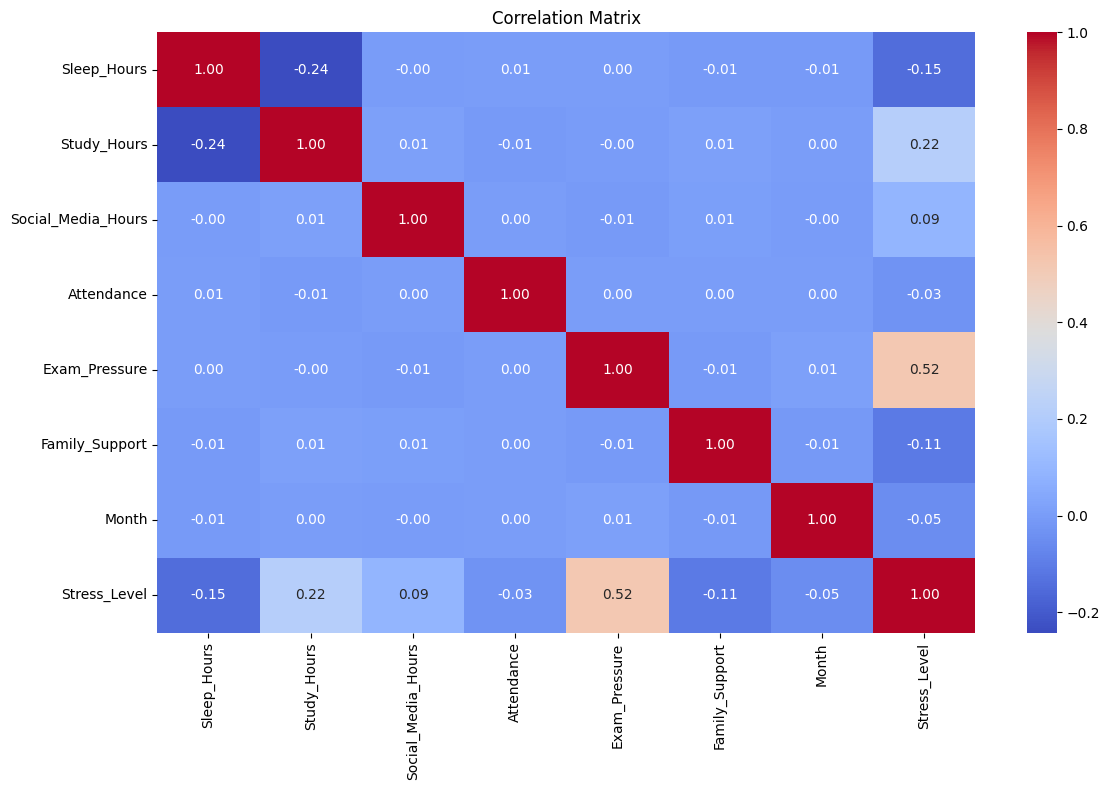

In [ ]:
# 5. VISUALIZATION
print("\n" + "="*50)
print("📈 VISUALIZATION")
print("="*50)

# Missing Values Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cmap='viridis', cbar=True)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.savefig('missing_heatmap.png', dpi=150)
plt.show()

# Distribution Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols[:6]):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{col} Distribution')

plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=150)
plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()


In [ ]:
# 6. DATA PREPROCESSING ---
print("\n" + "="*50)
print("🔧 DATA PREPROCESSING")
print("="*50)

df_clean = df.copy()

# 6.1 Handle Missing Values
print("\n📝 Handling Missing Values...")
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            # Fill with median
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"  ✅ {col}: filled with median")
        else:
            # Fill with mode
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f"  ✅ {col}: filled with mode")


🔧 DATA PREPROCESSING

📝 Handling Missing Values...
  ✅ Student_Type: filled with mode
  ✅ Sleep_Hours: filled with median
  ✅ Study_Hours: filled with median
  ✅ Social_Media_Hours: filled with median
  ✅ Attendance: filled with median
  ✅ Exam_Pressure: filled with median
  ✅ Family_Support: filled with median
  ✅ Month: filled with median



🔄 Removing 24 duplicate rows...
  ✅ Duplicates removed. New shape: (25476, 9)

📊 Handling Outliers...
Kolom                Outlier Sebelum Outlier Sesudah      Lower      Upper
---------------------------------------------------------------------------
Sleep_Hours                      162               0       2.57      10.42
Study_Hours                      229               0      -1.16      10.35
Social_Media_Hours               118               0      -1.58       8.58
Attendance                       232               0      51.33     112.53
Exam_Pressure                      0               0      -0.50      11.50
Family_Support                     0               0      -0.50      11.50
Month                              0               0      -3.50      16.50
Stress_Level                       0               0      -1.50       2.50
---------------------------------------------------------------------------
  ✅ Outliers capped with IQR method

📈 Membuat visualisasi boxplot...


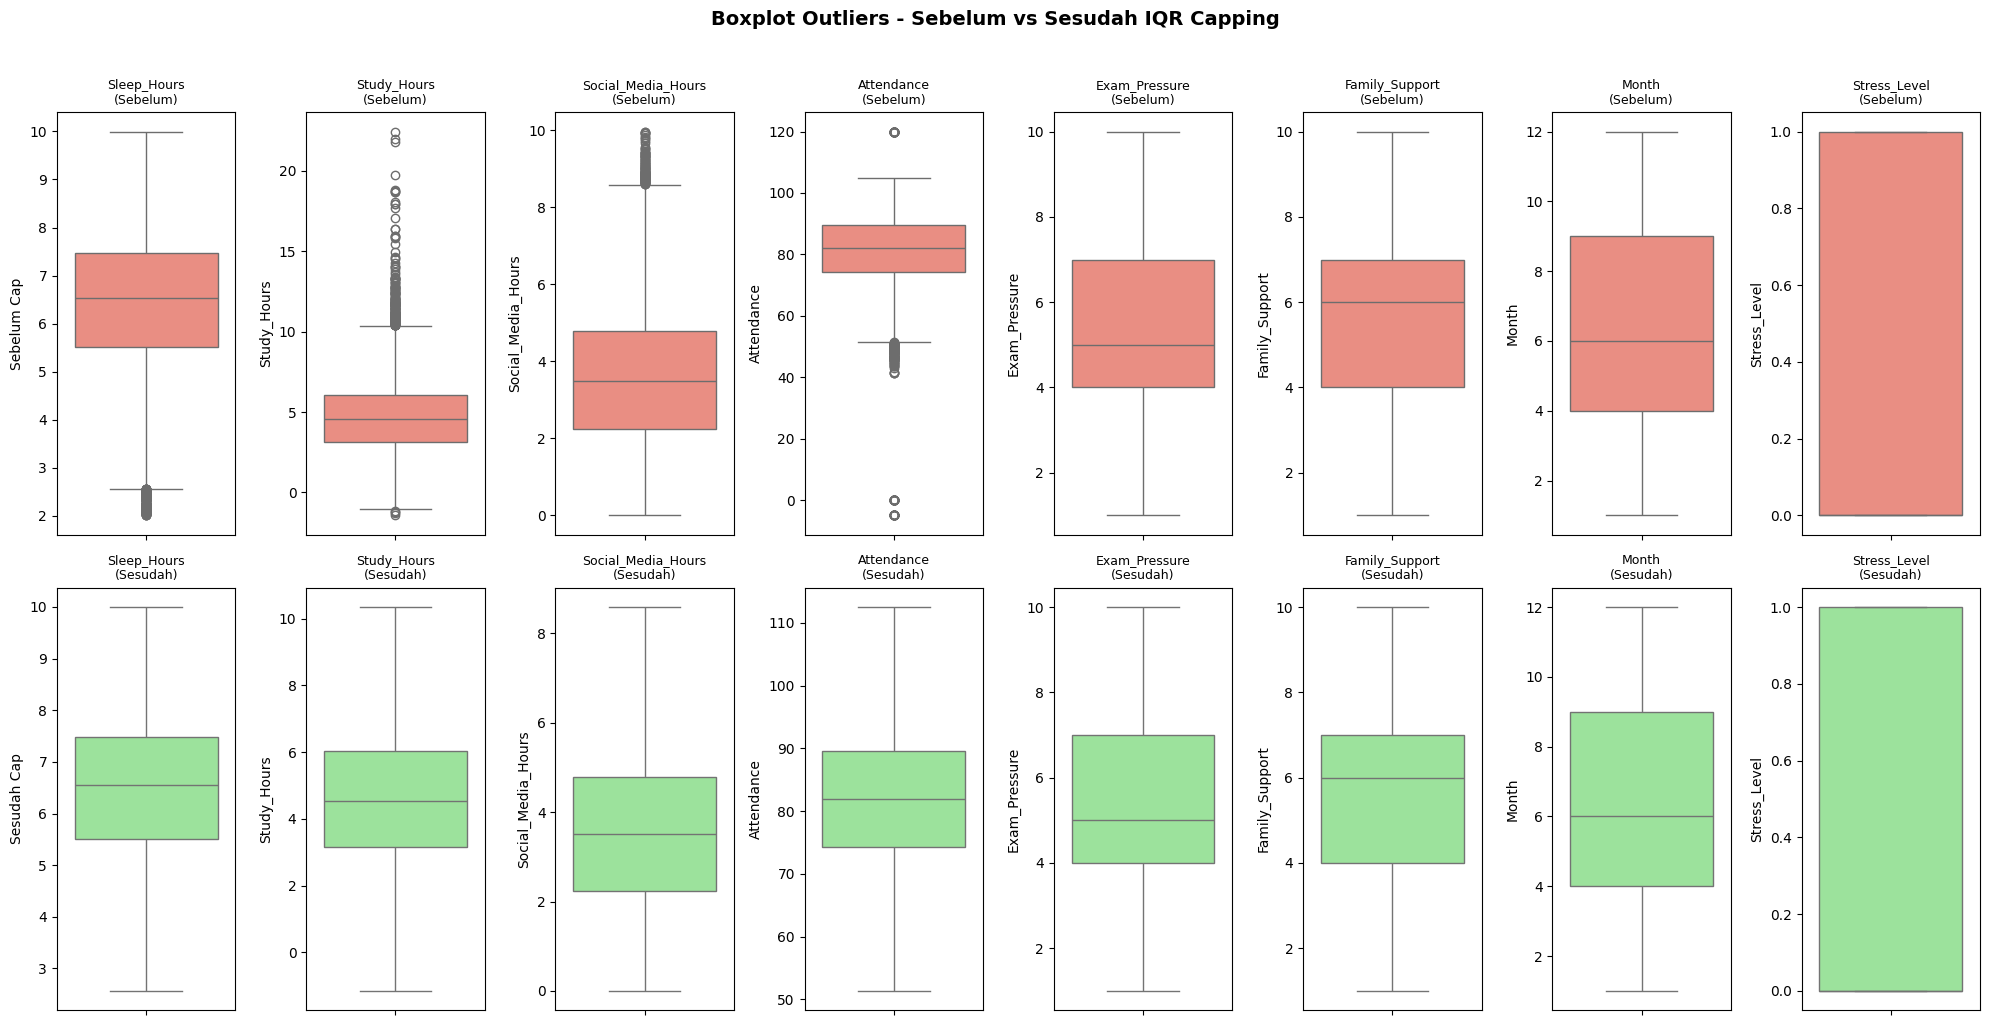

  ✅ Boxplot saved: boxplot_outliers.png


In [ ]:
# 6.2 Remove Duplicates
print(f"\n🔄 Removing {df_clean.duplicated().sum()} duplicate rows...")
df_clean.drop_duplicates(inplace=True)
print(f"  ✅ Duplicates removed. New shape: {df_clean.shape}")

# 6.3 Handle Outliers (Cap with IQR) + Visualisasi Boxplot
print("\n📊 Handling Outliers...")

df_before_cap = df_clean.copy()

# Tabel detail outlier
print(f"{'Kolom':<20} {'Outlier Sebelum':>15} {'Outlier Sesudah':>15} {'Lower':>10} {'Upper':>10}")
print("-" * 75)

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hitung outlier sebelum
    outlier_before = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    # Cap outlier
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

    # Hitung outlier sesudah
    outlier_after = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    print(f"{col:<20} {outlier_before:>15} {outlier_after:>15} {lower_bound:>10.2f} {upper_bound:>10.2f}")

print("-" * 75)
print("  ✅ Outliers capped with IQR method")

# ── Visualisasi Boxplot Sebelum vs Sesudah ──
print("\n📈 Membuat visualisasi boxplot...")

fig, axes = plt.subplots(2, len(numerical_cols), figsize=(20, 10))

for idx, col in enumerate(numerical_cols):
    # Sebelum
    sns.boxplot(y=df_before_cap[col], ax=axes[0][idx], color='salmon')
    axes[0][idx].set_title(f'{col}\n(Sebelum)', fontsize=9)
    axes[0][idx].set_xlabel('')

    # Sesudah
    sns.boxplot(y=df_clean[col], ax=axes[1][idx], color='lightgreen')
    axes[1][idx].set_title(f'{col}\n(Sesudah)', fontsize=9)
    axes[1][idx].set_xlabel('')

axes[0][0].set_ylabel('Sebelum Cap', fontsize=10)
axes[1][0].set_ylabel('Sesudah Cap', fontsize=10)

plt.suptitle('Boxplot Outliers - Sebelum vs Sesudah IQR Capping',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Boxplot saved: boxplot_outliers.png")

In [ ]:
# 6.4 Feature Encoding
# Cek kolom kategorikal
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Kolom kategorikal: {categorical_cols}")
print(f"Nilai unik Student_Type: {df_clean['Student_Type'].unique()}")

# One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoded_data = ohe.fit_transform(df_clean[categorical_cols])

# Buat nama kolom baru
encoded_cols = ohe.get_feature_names_out(categorical_cols)
print(f"\nKolom hasil encoding: {list(encoded_cols)}")

# Gabung ke dataframe
df_encoded = pd.DataFrame(encoded_data, columns=encoded_cols, index=df_clean.index)
df_clean = pd.concat([df_clean.drop(categorical_cols, axis=1), df_encoded], axis=1)

print(f"\nShape sesudah encoding: {df_clean.shape}")
print(f"\nPreview:\n{df_clean.head()}")
# 6.5 Feature Scaling
print("\n📐 Scaling Features...")
scaler = StandardScaler()
df_scaled = df_clean.copy()
valid_numerical = [col for col in numerical_cols if col in df_scaled.columns]
df_scaled[valid_numerical] = scaler.fit_transform(df_scaled[valid_numerical])
print("  ✅ Features scaled with StandardScaler")

# 6.6 Split Data perbandingan 80/20
print("\n📊 Splitting Data...")
target_col = 'Stress_Level'

X = df_scaled.drop(target_col, axis=1)
y = df_scaled[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"  ✅ Train size: {len(X_train):,}")
print(f"  ✅ Test size: {len(X_test):,}")

Kolom kategorikal: ['Student_Type']
Nilai unik Student_Type: ['school' 'college' 'working_student']

Kolom hasil encoding: ['Student_Type_school', 'Student_Type_working_student']

Shape sesudah encoding: (25476, 10)

Preview:
   Sleep_Hours  Study_Hours  Social_Media_Hours  Attendance  Exam_Pressure  \
0     6.868702     1.711722            3.176942   81.942959            8.0   
1     8.519088     3.251084            3.880787   93.978465            6.0   
2     4.498770     6.306885            2.936172   64.421253            7.0   
3     8.591223     2.384922            5.222832   81.868960            2.0   
4     5.329293     9.345179            7.815869   85.847982            5.0   

   Family_Support  Month  Stress_Level  Student_Type_school  \
0             7.0    2.0             1                  1.0   
1             4.0    3.0             1                  1.0   
2             1.0   12.0             1                  0.0   
3             7.0    7.0             0               

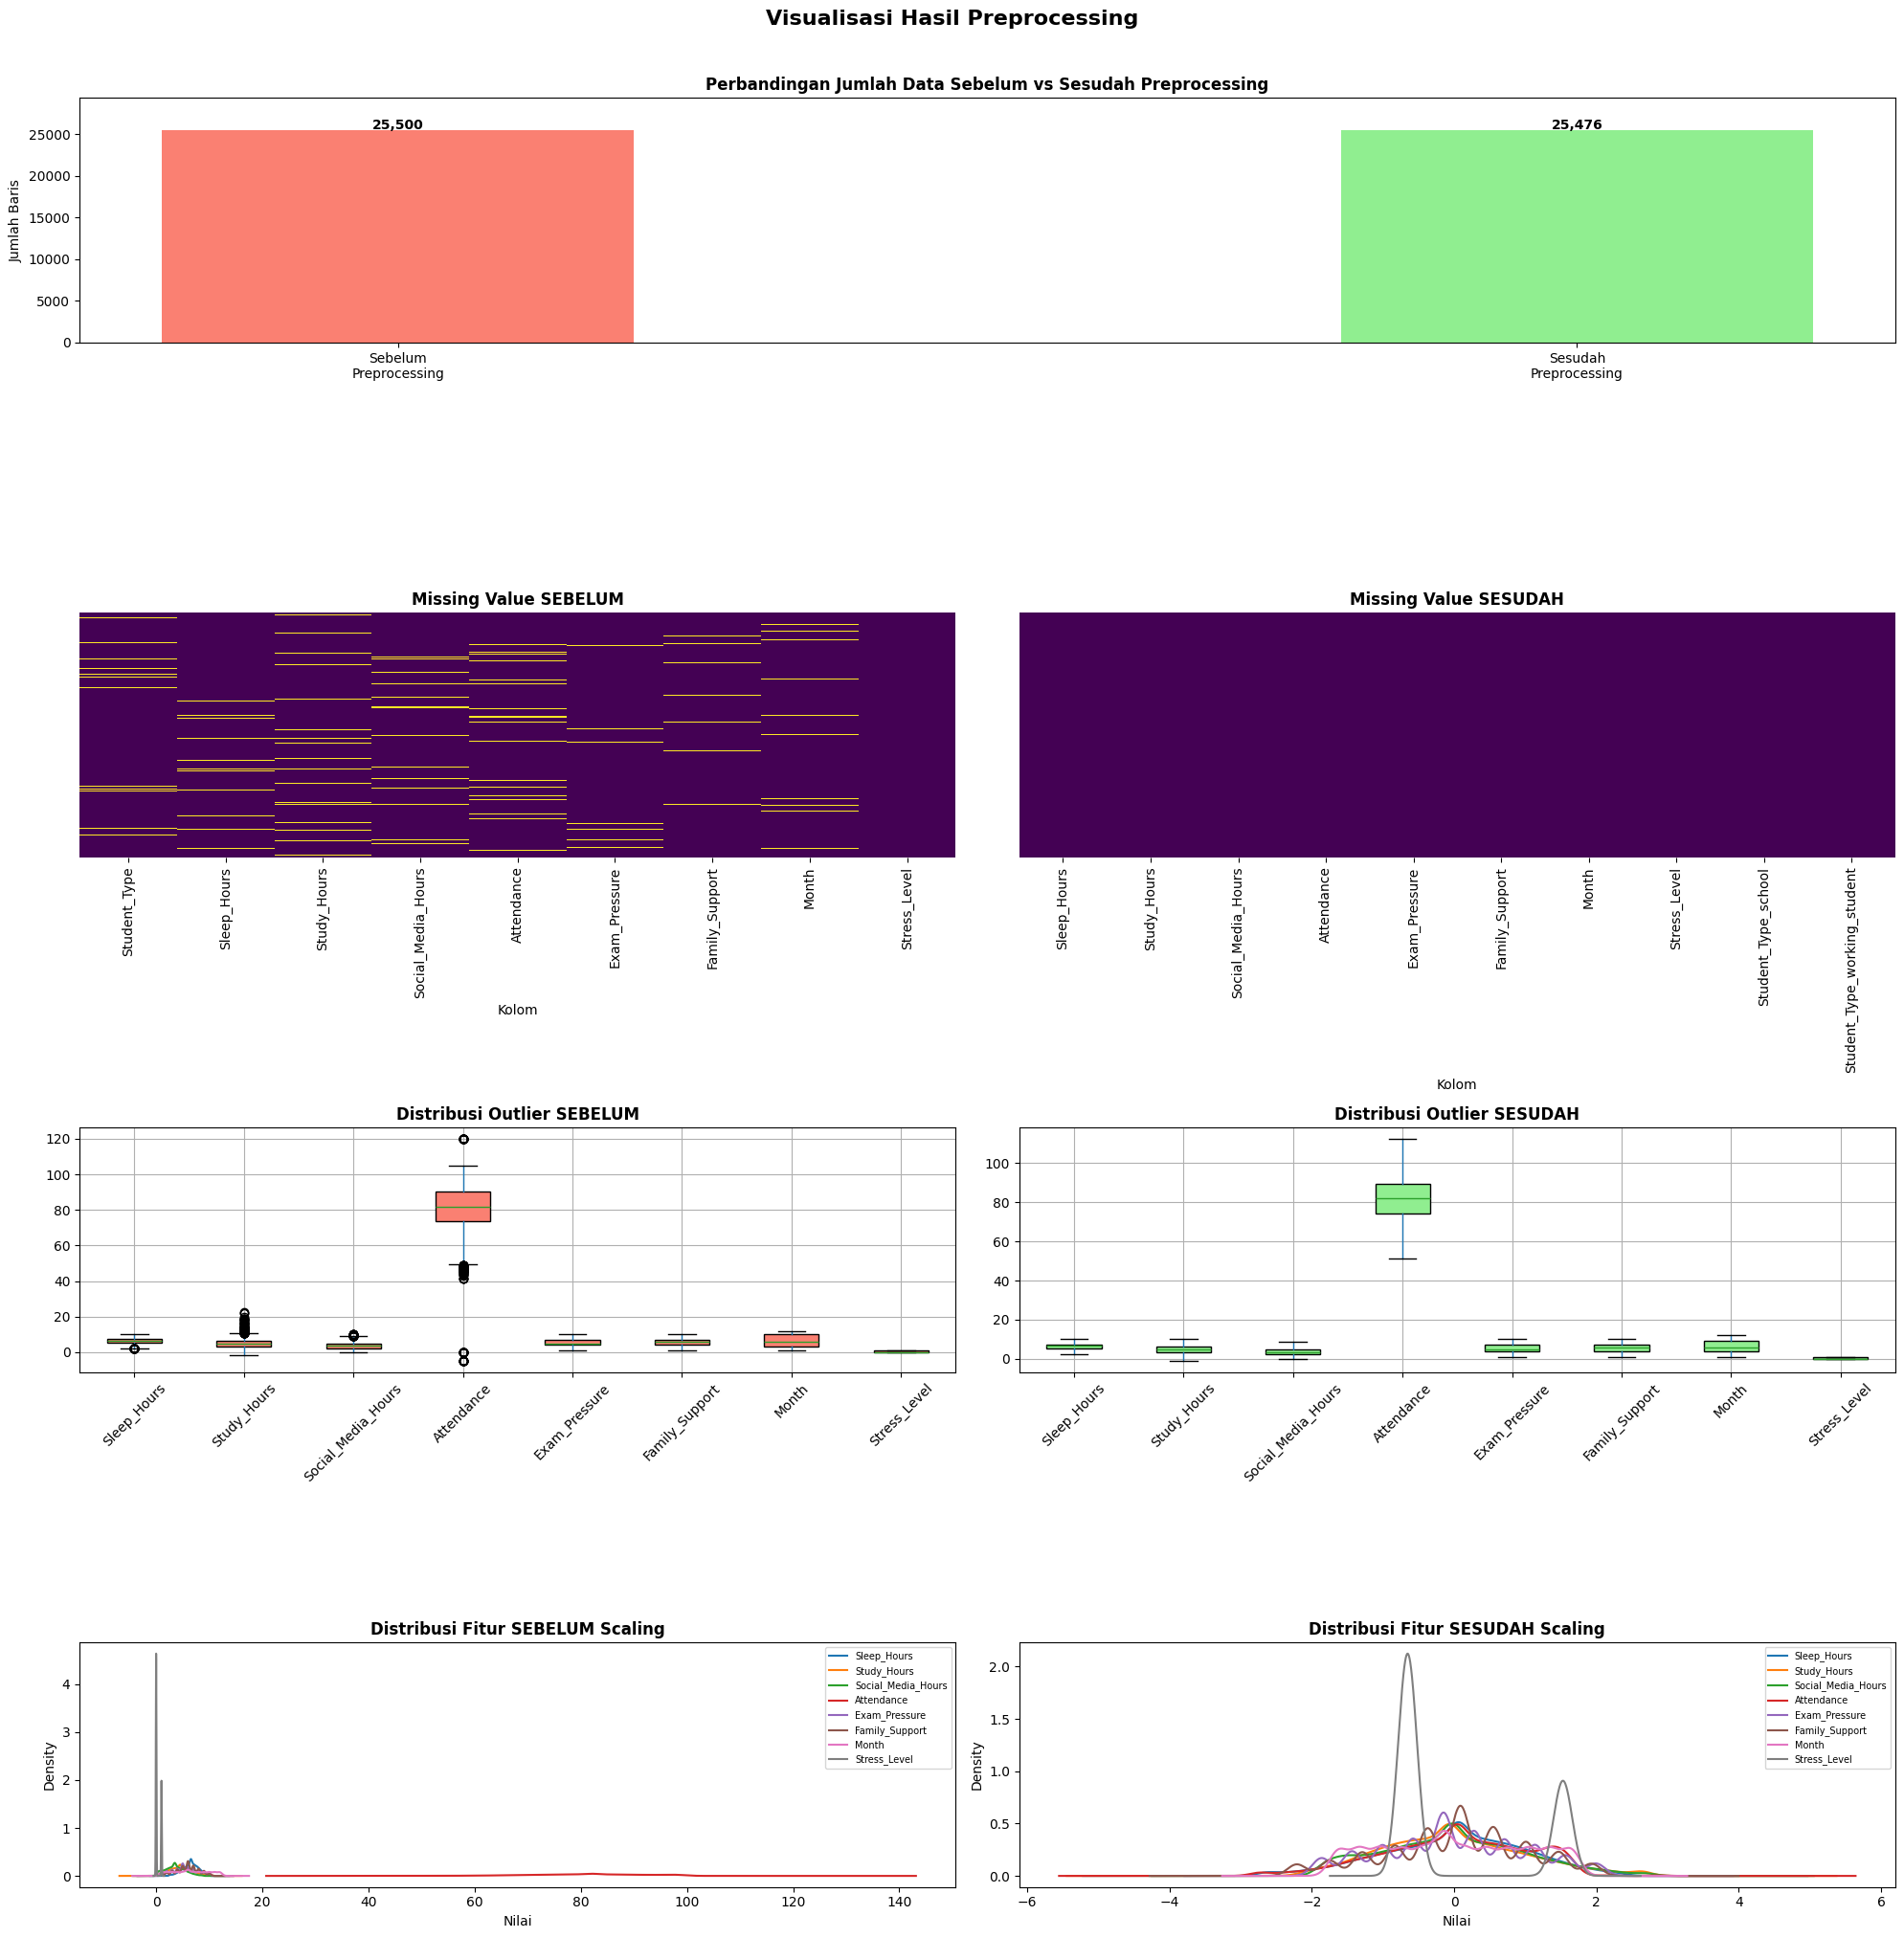

✅ Visualisasi preprocessing tersimpan!


In [ ]:
# Visualisasi FIX
fig = plt.figure(figsize=(20, 20))
fig.suptitle('Visualisasi Hasil Preprocessing', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Bar Chart: Perbandingan Shape ──
ax1 = fig.add_subplot(4, 1, 1)
kategori = ['Sebelum\nPreprocessing', 'Sesudah\nPreprocessing']
jumlah = [df.shape[0], df_clean.shape[0]]
bars = ax1.bar(kategori, jumlah, color=['salmon', 'lightgreen'], width=0.4)
ax1.set_title('Perbandingan Jumlah Data Sebelum vs Sesudah Preprocessing', fontweight='bold')
ax1.set_ylabel('Jumlah Baris')
for bar, val in zip(bars, jumlah):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontweight='bold')
ax1.set_ylim(0, max(jumlah) * 1.15)

# ── 2. Heatmap Missing Value ──
ax2 = fig.add_subplot(4, 2, 3)
sns.heatmap(df.isnull(), cmap='viridis', cbar=False, ax=ax2, yticklabels=False)
ax2.set_title('Missing Value SEBELUM', fontweight='bold')
ax2.set_xlabel('Kolom')

ax3 = fig.add_subplot(4, 2, 4)
sns.heatmap(df_clean.isnull(), cmap='viridis', cbar=False, ax=ax3, yticklabels=False)
ax3.set_title('Missing Value SESUDAH', fontweight='bold')
ax3.set_xlabel('Kolom')

# ── 3. Boxplot Outlier ──
ax4 = fig.add_subplot(4, 2, 5)
df[numerical_cols].boxplot(ax=ax4, patch_artist=True,
    boxprops=dict(facecolor='salmon'))
ax4.set_title('Distribusi Outlier SEBELUM', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

ax5 = fig.add_subplot(4, 2, 6)
df_clean[numerical_cols].boxplot(ax=ax5, patch_artist=True,
    boxprops=dict(facecolor='lightgreen'))
ax5.set_title('Distribusi Outlier SESUDAH', fontweight='bold')
ax5.tick_params(axis='x', rotation=45)

# ── 4. Distribusi Sebelum vs Sesudah Scaling ──
ax6 = fig.add_subplot(4, 2, 7)
df_clean[numerical_cols].plot(kind='density', ax=ax6, legend=True)
ax6.set_title('Distribusi Fitur SEBELUM Scaling', fontweight='bold')
ax6.set_xlabel('Nilai')
ax6.legend(fontsize=7)

ax7 = fig.add_subplot(4, 2, 8)
df_scaled[numerical_cols].plot(kind='density', ax=ax7, legend=True)
ax7.set_title('Distribusi Fitur SESUDAH Scaling', fontweight='bold')
ax7.set_xlabel('Nilai')
ax7.legend(fontsize=7)

plt.tight_layout()
plt.savefig('visualisasi_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi preprocessing tersimpan!")

In [ ]:
# 7. SAVE CLEANED DATA
print("\n" + "="*50)
print("💾 SAVE CLEANED DATA")
print("="*50)

df_clean.to_excel('dataset_cleaned.xlsx', index=False)
print("✅ Cleaned dataset saved: dataset_cleaned.xlsx")

df_scaled.to_excel('dataset_scaled.xlsx', index=False)
print("✅ Scaled dataset saved: dataset_scaled.xlsx")

# Download files
files.download('dataset_cleaned.xlsx')
files.download('dataset_scaled.xlsx')

print("\n🎉 PREPROCESSING COMPLETE!")
print("\n📊 FINAL DATA SUMMARY:")
print(f"   Original shape: {df.shape}")
print(f"   Cleaned shape: {df_clean.shape}")
print(f"   Missing values: {df_clean.isnull().sum().sum()}")
print(f"   Duplicates: {df_clean.duplicated().sum()}")


💾 SAVE CLEANED DATA
✅ Cleaned dataset saved: dataset_cleaned.xlsx
✅ Scaled dataset saved: dataset_scaled.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 PREPROCESSING COMPLETE!

📊 FINAL DATA SUMMARY:
   Original shape: (25500, 9)
   Cleaned shape: (25476, 10)
   Missing values: 0
   Duplicates: 3


# Penanganan Data Imbalance masih belum

tahap model

In [ ]:
from sklearn.model_selection import train_test_split

target_col = 'Stress_Level'

# X dari df_scaled (fitur sudah di-scale)
# y dari df_clean (target tetap 0/1, tidak di-scale)
X = df_scaled.drop(target_col, axis=1)
y = df_clean[target_col]  # ← ambil dari df_clean, bukan df_scaled

# Samakan index dulu
X = X.loc[y.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Train size : {len(X_train):,}")
print(f"✅ Test size  : {len(X_test):,}")
print(f"\nCek nilai unik y_train: {y_train.unique()}")  # harusnya [0, 1]

✅ Train size : 20,380
✅ Test size  : 5,096

Cek nilai unik y_train: [0 1]


⚖️ Menyeimbangkan data dengan SMOTE...
Sebelum SMOTE:
  Tidak Stres (0) : 14,267
  Stres (1)       : 6,113

Sesudah SMOTE:
  Tidak Stres (0) : 14,267
  Stres (1)       : 14,267

🤖 MODELING DENGAN SMOTE

🔄 Training Random Forest...
  ✅ Accuracy : 0.8099 (80.99%)
  ✅ AUC-ROC  : 0.8612

📋 Classification Report Random Forest:
              precision    recall  f1-score   support

 Tidak Stres       0.86      0.87      0.87      3570
       Stres       0.69      0.66      0.67      1526

    accuracy                           0.81      5096
   macro avg       0.77      0.77      0.77      5096
weighted avg       0.81      0.81      0.81      5096


🔄 Training Logistic Regression...
  ✅ Accuracy : 0.7847 (78.47%)
  ✅ AUC-ROC  : 0.8683

📋 Classification Report Logistic Regression:
              precision    recall  f1-score   support

 Tidak Stres       0.90      0.78      0.84      3570
       Stres       0.61      0.79      0.69      1526

    accuracy                           0.78      50

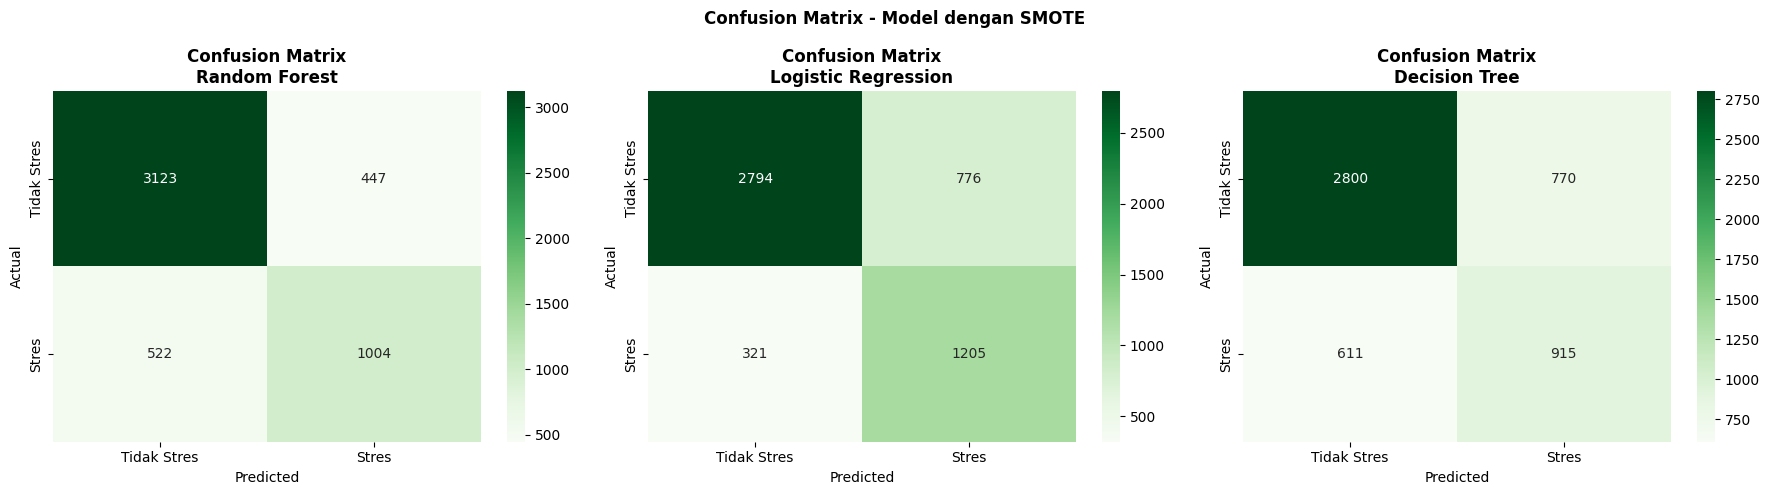

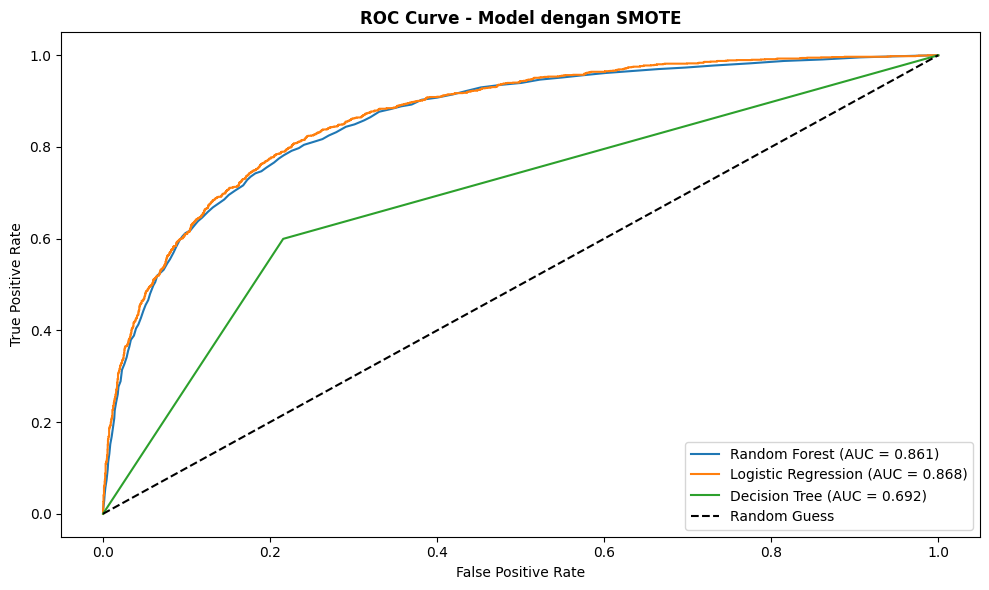


🏆 Model Terbaik (SMOTE): Logistic Regression
   Accuracy : 78.47%
   AUC-ROC  : 0.8683

📊 PERBANDINGAN SEBELUM vs SESUDAH SMOTE
Model                      Acc Sebelum  Acc Sesudah  AUC Sebelum  AUC Sesudah
---------------------------------------------------------------------------
Random Forest                   0.8116       0.8099       0.8635       0.8612
Logistic Regression             0.7845       0.7847       0.8687       0.8683
Decision Tree                   0.7425       0.7290       0.6894       0.6920


In [ ]:
!pip install imbalanced-learn

# ── Penerapan SMOTE ──
print("⚖️ Menyeimbangkan data dengan SMOTE...")
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"Sebelum SMOTE:")
print(f"  Tidak Stres (0) : {(y_train == 0).sum():,}")
print(f"  Stres (1)       : {(y_train == 1).sum():,}")
print(f"\nSesudah SMOTE:")
print(f"  Tidak Stres (0) : {(y_train_sm == 0).sum():,}")
print(f"  Stres (1)       : {(y_train_sm == 1).sum():,}")

# ── Definisi Model (tanpa class_weight) ──
models_sm = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results_sm = {}

print("\n" + "="*50)
print("🤖 MODELING DENGAN SMOTE")
print("="*50)

for nama, model in models_sm.items():
    print(f"\n🔄 Training {nama}...")

    # Training pakai data SMOTE
    model.fit(X_train_sm, y_train_sm)

    # Prediksi tetap pakai X_test asli (tidak di-SMOTE)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results_sm[nama] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': acc,
        'auc': auc
    }

    print(f"  ✅ Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  ✅ AUC-ROC  : {auc:.4f}")
    print(f"\n📋 Classification Report {nama}:")
    print(classification_report(y_test, y_pred,
          target_names=['Tidak Stres', 'Stres']))

# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (nama, result) in enumerate(results_sm.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                xticklabels=['Tidak Stres', 'Stres'],
                yticklabels=['Tidak Stres', 'Stres'])
    axes[idx].set_title(f'Confusion Matrix\n{nama}', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')
plt.suptitle('Confusion Matrix - Model dengan SMOTE', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_smote.png', dpi=150)
plt.show()

# ── ROC Curve ──
plt.figure(figsize=(10, 6))
for nama, result in results_sm.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    plt.plot(fpr, tpr, label=f"{nama} (AUC = {result['auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model dengan SMOTE', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_smote.png', dpi=150)
plt.show()

# ── Model Terbaik ──
best_sm = max(results_sm, key=lambda x: results_sm[x]['auc'])
print(f"\n🏆 Model Terbaik (SMOTE): {best_sm}")
print(f"   Accuracy : {results_sm[best_sm]['accuracy']*100:.2f}%")
print(f"   AUC-ROC  : {results_sm[best_sm]['auc']:.4f}")

# ── Perbandingan Sebelum vs Sesudah SMOTE ──
print("\n📊 PERBANDINGAN SEBELUM vs SESUDAH SMOTE")
print(f"{'Model':<25} {'Acc Sebelum':>12} {'Acc Sesudah':>12} {'AUC Sebelum':>12} {'AUC Sesudah':>12}")
print("-" * 75)
for nama in results.keys():
    acc_before = results[nama]['accuracy']
    acc_after = results_sm[nama]['accuracy']
    auc_before = results[nama]['auc']
    auc_after = results_sm[nama]['auc']
    print(f"{nama:<25} {acc_before:>12.4f} {acc_after:>12.4f} {auc_before:>12.4f} {auc_after:>12.4f}")

Tanpa di tangani data imbalance

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

print("="*50)
print("🤖 MODELING")
print("="*50)

# Definisikan model
models = {
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42)
}

# Simpan hasil tiap model
results = {}

for nama, model in models.items():
    print(f"\n🔄 Training {nama}...")

    # Training
    model.fit(X_train, y_train)                   # ← training/belajar dari data train

    # Prediksi
    y_pred = model.predict(X_test)                # ← prediksi data test
    y_prob = model.predict_proba(X_test)[:, 1]    # ← probabilitas prediksi 0-1

    # Evaluasi
    acc = accuracy_score(y_test, y_pred)          # % prediksi yang benar secara keseluruhan
    auc = roc_auc_score(y_test, y_prob)           # Kemampuan model bedakan stres vs tidak stres (0.5 = random, 1.0 = sempurna)

    results[nama] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': acc,
        'auc': auc
    }

    print(f"  ✅ Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  ✅ AUC-ROC  : {auc:.4f}")
    print(f"\n📋 Classification Report {nama}:")
    print(classification_report(y_test, y_pred,
          target_names=['Tidak Stres', 'Stres']))

🤖 MODELING

🔄 Training Random Forest...
  ✅ Accuracy : 0.8116 (81.16%)
  ✅ AUC-ROC  : 0.8635

📋 Classification Report Random Forest:
              precision    recall  f1-score   support

 Tidak Stres       0.84      0.91      0.87      3570
       Stres       0.73      0.58      0.65      1526

    accuracy                           0.81      5096
   macro avg       0.78      0.75      0.76      5096
weighted avg       0.81      0.81      0.80      5096


🔄 Training Logistic Regression...
  ✅ Accuracy : 0.7845 (78.45%)
  ✅ AUC-ROC  : 0.8687

📋 Classification Report Logistic Regression:
              precision    recall  f1-score   support

 Tidak Stres       0.90      0.78      0.84      3570
       Stres       0.61      0.80      0.69      1526

    accuracy                           0.78      5096
   macro avg       0.75      0.79      0.76      5096
weighted avg       0.81      0.78      0.79      5096


🔄 Training Decision Tree...
  ✅ Accuracy : 0.7425 (74.25%)
  ✅ AUC-ROC  : 0.68

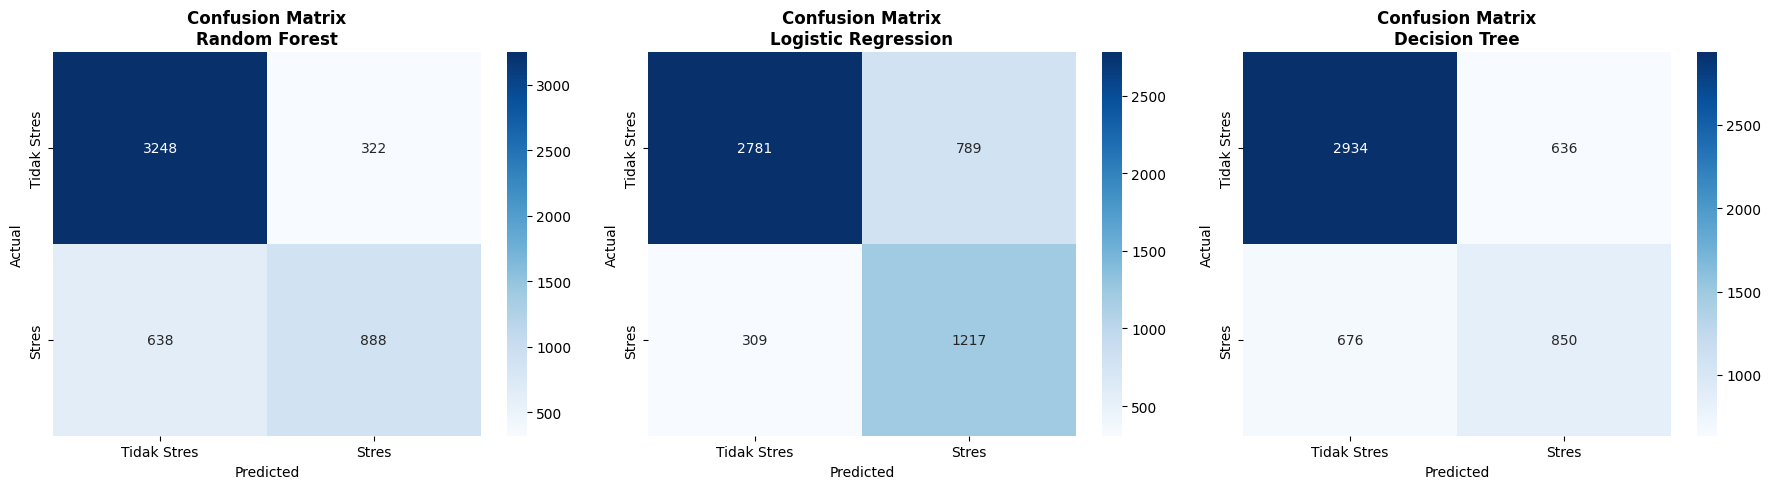

In [ ]:
# ── Visualisasi Confusion Matrix ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nama, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Tidak Stres', 'Stres'],
                yticklabels=['Tidak Stres', 'Stres'])
    axes[idx].set_title(f'Confusion Matrix\n{nama}', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Prediksi
                 Tidak Stres  |  Stres
Aktual  Tidak Stres  [TN]     |  [FP]
        Stres        [FN]     |  [TP]

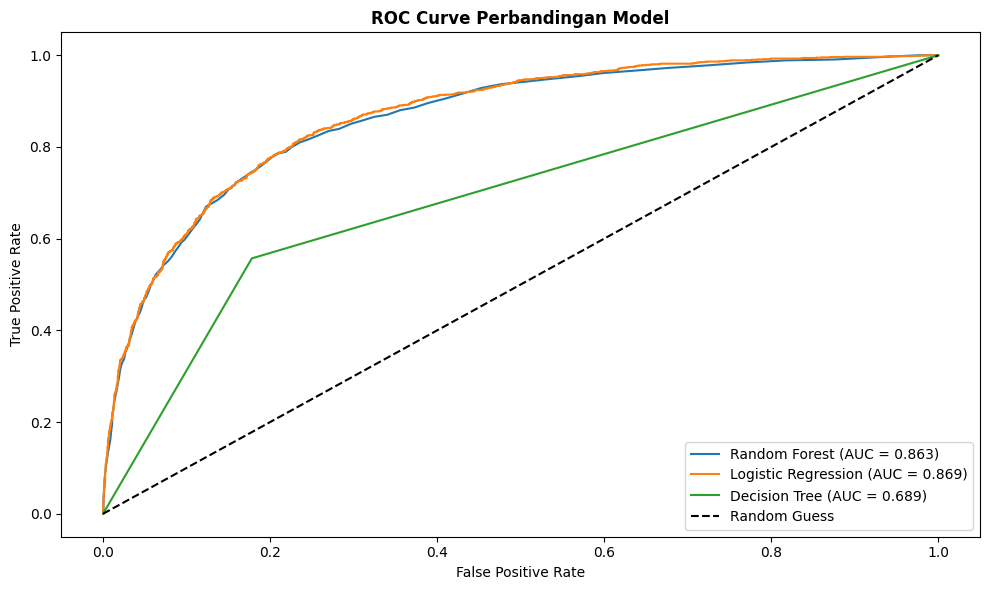

In [ ]:
# ── Visualisasi ROC Curve ──
plt.figure(figsize=(10, 6))

for nama, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    plt.plot(fpr, tpr, label=f"{nama} (AUC = {result['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Perbandingan Model', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

fpr\False Positive Rate (sumbu X)
tpr\True Positive Rate (sumbu Y)
Garis putus-putus\Garis "model random" — model bagus harus di atas garis ini
AUC makin dekat 1.0\Model makin bagus

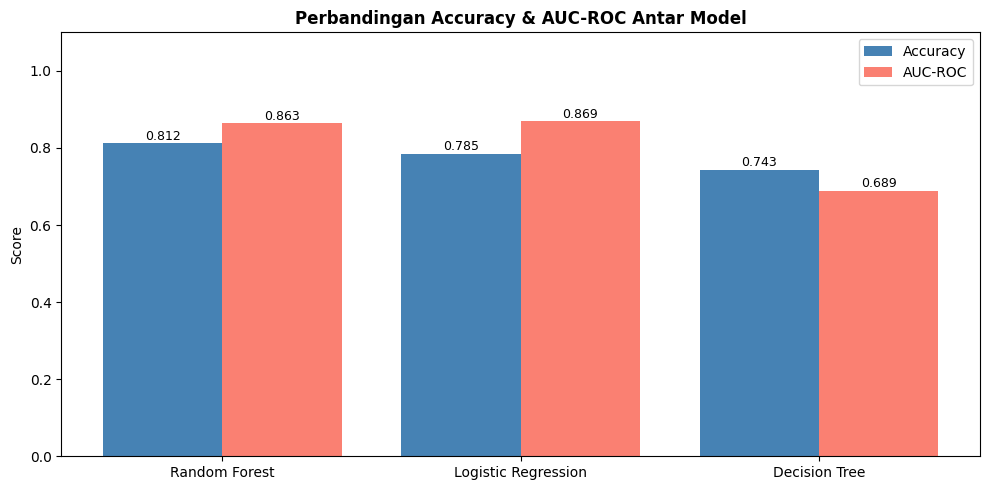


🏆 Model Terbaik: Logistic Regression
   Accuracy : 78.45%
   AUC-ROC  : 0.8687


In [ ]:
# ── Perbandingan Akurasi Semua Model ──
nama_model = list(results.keys())
akurasi = [results[m]['accuracy'] for m in nama_model]
auc_scores = [results[m]['auc'] for m in nama_model]

x = range(len(nama_model))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - 0.2 for i in x], akurasi, 0.4,
               label='Accuracy', color='steelblue')
bars2 = ax.bar([i + 0.2 for i in x], auc_scores, 0.4,
               label='AUC-ROC', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(nama_model)
ax.set_ylim(0, 1.1)
ax.set_title('Perbandingan Accuracy & AUC-ROC Antar Model', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150)
plt.show()

# ── Kesimpulan Model Terbaik ──
best_model = max(results, key=lambda x: results[x]['auc'])        #Pilih model terbaik berdasarkan AUC tertinggi — bukan accuracy, karena data imbalance sehingga AUC lebih representatif.
print(f"\n🏆 Model Terbaik: {best_model}")
print(f"   Accuracy : {results[best_model]['accuracy']*100:.2f}%")
print(f"   AUC-ROC  : {results[best_model]['auc']:.4f}")